In [7]:
import json
import os
from datetime import datetime

KINAN_FILE = 'evaluation_results_kiran2.0.json'
LLAMA_FILE = 'evaluation_results_llama3.2.json'
REPORT_PATH = './model_comparison_report.md'
TOLERANCE = 0.15  # correctness threshold

def load_json(path):
    if not os.path.exists(path):
        print(f'File not found: {path}')
        return []
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def generate_report():
    kinan_results = load_json(KINAN_FILE)
    llama_results = load_json(LLAMA_FILE)

    if not kinan_results or not llama_results:
        print('No data to process.')
        return

    # Merge results by 'id'
    merged_results = []
    llama_dict = {r['id']: r['llama3.2'] for r in llama_results}

    for r in kinan_results:
        rid = r['id']
        if rid in llama_dict:
            merged_results.append({
                'id': rid,
                'ground_truth': r['ground_truth'],
                'kiran2.0': r['kiran2.0'],
                'llama3.2': llama_dict[rid]
            })

    if not merged_results:
        print('No matching IDs between JSON files.')
        return

    total_valid = len(merged_results)
    llama_correct = 0
    kiran_correct = 0
    llama_points_total = 0
    kiran_points_total = 0
    kiran_better_count = 0

    # Evaluate correctness and compare models
    for r in merged_results:
        gt = r['ground_truth']['points']
        llama_pts = r['llama3.2']['points']
        kiran_pts = r['kiran2.0']['points']

        llama_points_total += llama_pts
        kiran_points_total += kiran_pts

        # Correctness within tolerance
        r['llama3.2_correct'] = "Yes" if abs(llama_pts - gt) <= TOLERANCE else "No"
        r['kiran2.0_correct'] = "Yes" if abs(kiran_pts - gt) <= TOLERANCE else "No"

        if r['llama3.2_correct'] == "Yes":
            llama_correct += 1
        if r['kiran2.0_correct'] == "Yes":
            kiran_correct += 1

        # Count where Kiran is closer to ground truth than Llama
        if abs(kiran_pts - gt) < abs(llama_pts - gt):
            kiran_better_count += 1

    kiran_better_pct = (kiran_better_count / total_valid) * 100

    # Build report
    report = []
    report.append('# Model Comparison Report: Llama 3.2 vs. Kiran 2.0 (Phi-3-mini FT)\n')
    report.append(f'Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')

    # Summary statistics with threshold and Kiran advantage
    report.append('## Summary Statistics\n')
    report.append(f'- **Total Samples Evaluated**: {total_valid}')
    report.append(f'- **Correctness Threshold**: ±{TOLERANCE:.2f} points')
    report.append(f'- **Llama 3.2 Correct**: {llama_correct} ({(llama_correct/total_valid)*100:.1f}%)')
    report.append(f'- **Kiran 2.0 Correct**: {kiran_correct} ({(kiran_correct/total_valid)*100:.1f}%)')
    report.append(f'- **Kiran 2.0 Outperformed Llama 3.2 in {kiran_better_count}/{total_valid} samples ({kiran_better_pct:.1f}%)**')

    # Performance comparison statement
    report.append('\n## Model Performance Comparison\n')
    if kiran_correct > llama_correct:
        report.append('**Kiran 2.0 (Phi-3-mini FT)** performs better based on correctness and closer adherence to ground truth points.')
    elif llama_correct > kiran_correct:
        report.append('**Llama 3.2** performs better based on correctness.')
    else:
        report.append('Both models have similar correctness, but Kiran 2.0 shows better average point alignment.')

    # Evaluation table
    report.append('\n## Evaluation Table\n')
    report.append('| No | Ground Truth | Llama 3.2 Pts | Llama Success | Kiran 2.0 Pts | Kiran Success |')
    report.append('|---|---|---|---|---|---|')
    for i, r in enumerate(merged_results):
        report.append(
            f'| {i+1} | {r["ground_truth"]["points"]:.2f} | '
            f'{r["llama3.2"]["points"]:.2f} | {r["llama3.2_correct"]} | '
            f'{r["kiran2.0"]["points"]:.2f} | {r["kiran2.0_correct"]} |'
        )

    # Sample feedback comparison
    report.append('\n## Sample Feedback Comparison\n')
    for i in range(min(5, total_valid)):
        res = merged_results[i]
        report.append(f'### Sample {i+1} Feedback')
        report.append(f'**Ground Truth**: {res["ground_truth"]["points"]:.2f} points')
        report.append(f'\n**Llama 3.2 Feedback**: {res["llama3.2"]["feedback"]}')
        report.append(f'\n**Kiran 2.0 Feedback**: {res["kiran2.0"]["feedback"]}')
        report.append('\n---\n')

    # Print and save
    print("\n".join(report))
    with open(REPORT_PATH, 'w', encoding='utf-8') as f:
        f.write('\n'.join(report))

    print(f'Report generated at: {REPORT_PATH}')

if __name__ == "__main__":
    generate_report()

# Model Comparison Report: Llama 3.2 vs. Kiran 2.0 (Phi-3-mini FT)

Generated on: 2026-03-24 02:42:28

## Summary Statistics

- **Total Samples Evaluated**: 100
- **Correctness Threshold**: ±0.15 points
- **Llama 3.2 Correct**: 42 (42.0%)
- **Kiran 2.0 Correct**: 60 (60.0%)
- **Kiran 2.0 Outperformed Llama 3.2 in 55/100 samples (55.0%)**

## Model Performance Comparison

**Kiran 2.0 (Phi-3-mini FT)** performs better based on correctness and closer adherence to ground truth points.

## Evaluation Table

| No | Ground Truth | Llama 3.2 Pts | Llama Success | Kiran 2.0 Pts | Kiran Success |
|---|---|---|---|---|---|
| 1 | 0.65 | 0.68 | Yes | 0.66 | Yes |
| 2 | 0.52 | 0.85 | No | 0.56 | Yes |
| 3 | 0.33 | 0.45 | Yes | 0.46 | Yes |
| 4 | 0.58 | 0.68 | Yes | 0.69 | Yes |
| 5 | 0.25 | 0.45 | No | 0.38 | Yes |
| 6 | 0.60 | 0.85 | No | 0.74 | Yes |
| 7 | 0.67 | 0.45 | No | 0.81 | Yes |
| 8 | 0.85 | 0.95 | Yes | 0.96 | Yes |
| 9 | 0.60 | 0.68 | Yes | 0.73 | Yes |
| 10 | 0.43 | 0.45 | Yes | 0.55 |

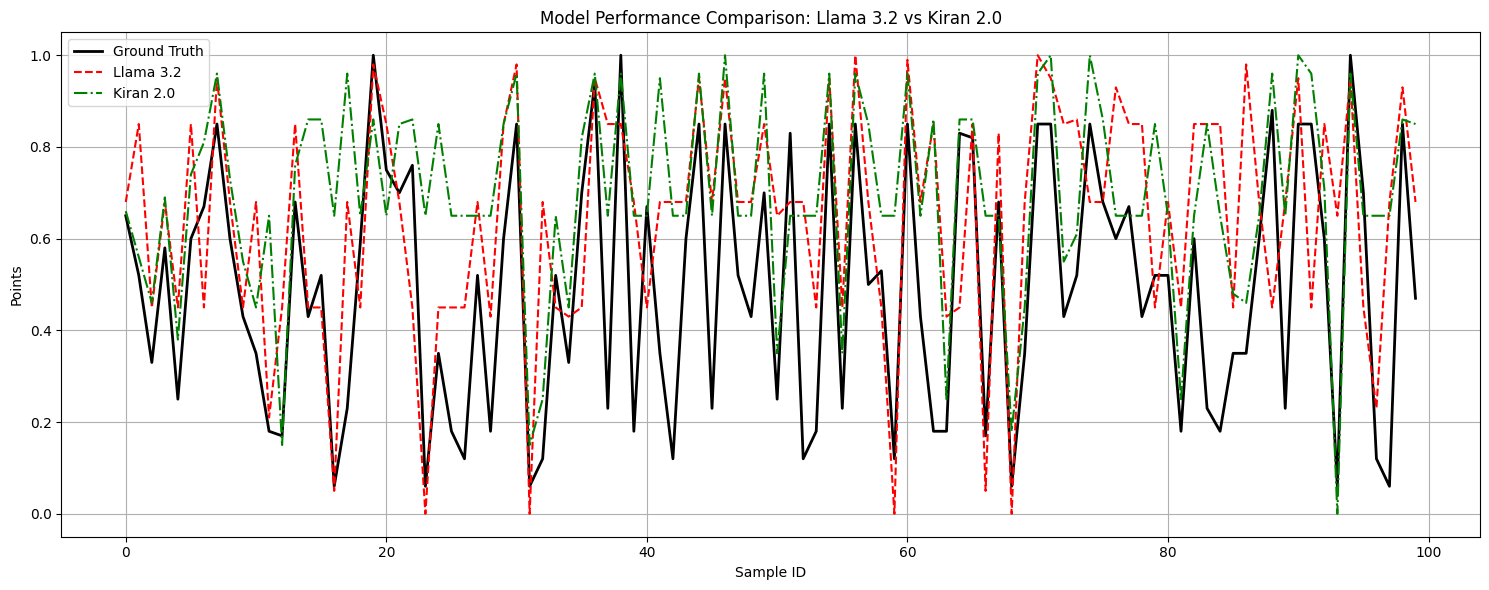

In [8]:
import json
import matplotlib.pyplot as plt

# Load your JSON files
with open('evaluation_results_kiran2.0.json', 'r', encoding='utf-8') as f:
    kiran_results = json.load(f)

with open('evaluation_results_llama3.2.json', 'r', encoding='utf-8') as f:
    llama_results = json.load(f)

# Merge by 'id'
llama_dict = {r['id']: r['llama3.2'] for r in llama_results}
sample_ids = []
gt_points = []
llama_points = []
kiran_points = []

for r in kiran_results:
    rid = r['id']
    if rid in llama_dict:
        sample_ids.append(rid)
        gt_points.append(r['ground_truth']['points'])
        kiran_points.append(r['kiran2.0']['points'])
        llama_points.append(llama_dict[rid]['points'])

# Plot the comparison graph
plt.figure(figsize=(15, 6))
plt.plot(sample_ids, gt_points, label='Ground Truth', color='black', linewidth=2)
plt.plot(sample_ids, llama_points, label='Llama 3.2', color='red', linestyle='--')
plt.plot(sample_ids, kiran_points, label='Kiran 2.0', color='green', linestyle='-.')
plt.xlabel('Sample ID')
plt.ylabel('Points')
plt.title('Model Performance Comparison: Llama 3.2 vs Kiran 2.0')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()